# alugaFloripa: Predição de Aluguel Residencial em Florianópolis - Regressão

**Problema preditivo:** estimar o valor mensal de aluguel (`valor`) de um imóvel residencial em Florianópolis a partir de suas características físicas e comerciais. É um problema de **regressão**, pois o alvo é uma variável numérica contínua, em **reais (BRL)**.

**Por que isso importa:** uma estimativa de aluguel confiável pode ajudar proprietários, locatários e imobiliárias a tomarem decisões melhores, evitando preços muito acima ou abaixo do praticado no mercado local.

**Dataset:** `full_history.csv`, base pública de anúncios de imóveis para aluguel em Florianópolis, obtida no Kaggle. Neste projeto, será utilizado o recorte de imóveis com `categoria` igual a **Residencial** e `periodicidade` igual a **Mês**.

## Configuração do ambiente

In [1]:
import os  # Permite interagir com pastas e caminhos do sistema operacional
import sys  # Permite alterar a lista de caminhos que o Python usa para importar módulos
from pathlib import Path  # Ajuda a trabalhar com caminhos de arquivos de forma segura

# Garante que o notebook encontre a raiz do projeto,
# mesmo que ele seja executado dentro da pasta notebooks/
_root = Path.cwd()  # Captura a pasta atual onde o notebook está sendo executado

# Sobe pelas pastas até encontrar a pasta src/
while not (_root / "src").is_dir() and _root != _root.parent:
    _root = _root.parent  # Volta uma pasta acima

os.chdir(_root)  # Define a raiz do projeto como pasta principal de execução

# Adiciona a raiz do projeto ao caminho de importação do Python,
# permitindo importar arquivos da pasta src/
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

print(f"Raiz do projeto configurada em: {_root}")  # Mostra o caminho encontrado

Raiz do projeto configurada em: c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\Desenvolvimento de IA para Análise Preditiva [T2]\IA\PRojeto Final-M1\alugaFloripa


## Fase 1 - Análise Exploratória de Dados (EDA)

### Importação das bibliotecas

In [2]:
import pandas as pd  # leitura, organização e análise de dados em tabelas
import numpy as np  # operações numéricas e cálculos com arrays

import matplotlib.pyplot as plt  # criação de gráficos
import seaborn as sns  # criação de gráficos estatísticos

import statsmodels.api as sm  # análises estatísticas auxiliares
from statsmodels.stats.outliers_influence import variance_inflation_factor  # cálculo do VIF para avaliar multicolinearidade

from sklearn.model_selection import train_test_split  # função para separar dados de treino e teste
from sklearn.preprocessing import StandardScaler  # padronizador de variáveis numéricas
from sklearn.linear_model import LinearRegression  # modelo de Regressão Linear
from sklearn.ensemble import RandomForestRegressor  # modelo Random Forest para segunda versão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # métricas de avaliação de regressão

import joblib  # biblioteca para salvar e carregar modelos treinados
import json  # biblioteca para salvar métricas em arquivo JSON
from datetime import datetime  # registrar data/hora das versões do modelo

# Funções e parâmetros reutilizáveis do projeto, implementados em src/
from src.config import RAW_FILE, PROCESSED_FILE, FINAL_FILE, FIGURES_DIR, MODEL_FILE, METRICS_FILE, TARGET_COL, TEST_SIZE, RANDOM_STATE  # importa caminhos e parâmetros centrais
from src.dataset import load_raw_data, save_processed_data, load_processed_data, save_final_data, load_final_data  # importa funções de leitura e salvamento dos datasets
from src.plots import plot_histogram, plot_boxplots, plot_scatter, plot_correlation_heatmap, plot_observed_vs_predicted, plot_residuals  # Importa funções modularizadas para gerar e salvar gráficos
from src.features import clean_data, cap_iqr, add_features, select_final_columns  # Importa funções modularizadas de limpeza, tratamento de outliers e criação de features

pd.set_option("display.max_columns", None)  # configura o pandas para mostrar todas as colunas do DataFrame
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")  # formata números com 2 casas decimais

sns.set_theme(style="whitegrid", palette="muted")  # define estilo visual dos gráficos

In [3]:
# Carrega o dataset bruto usando a função de src/dataset.py
df = load_raw_data()

print("INSPEÇÃO INICIAL DO DATASET")
print(f"Shape: {df.shape}")

print(f"\nTipos de dados:\n{df.dtypes}")

print(f"\nValores nulos por coluna:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

df.describe()

INSPEÇÃO INICIAL DO DATASET
Shape: (36092, 24)

Tipos de dados:
Unnamed: 0          int64
data               object
fonte              object
id                  int64
descricao          object
tipo               object
endereco           object
rua                object
numero            float64
bairro             object
cidade             object
valor               int64
periodicidade      object
condominio        float64
area              float64
qtd_banheiros     float64
qtd_quartos       float64
qtd_vagas         float64
url                object
amenities          object
categoria          object
valor_total       float64
valor_m2          float64
valor_condo_m2    float64
dtype: object

Valores nulos por coluna:
rua               9175
numero           18455
qtd_banheiros     2909
qtd_quartos      15125
qtd_vagas        10568
amenities         8491
dtype: int64


,Unnamed: 0,id,numero,valor,condominio,area,qtd_banheiros,qtd_quartos,qtd_vagas,valor_total,valor_m2,valor_condo_m2
count,"36,092.00","36,092.00","17,637.00","36,092.00","36,092.00","36,092.00","33,183.00","20,967.00","25,524.00","36,092.00","36,092.00","36,092.00"
mean,"3,698.61","2,615,194,682.23","1,043.50","7,006.88",308.45,177.01,2.30,2.71,1.98,"7,315.33",48.72,2.91
std,"2,132.01","221,482,894.26","11,950.51","9,275.19",664.49,228.38,1.65,1.37,1.41,"9,441.35",33.34,4.90
min,0.00,"62,568,647.00",1.00,100.00,0.00,4.00,1.00,1.00,1.00,100.00,1.00,0.00
25%,"1,855.00","2,628,922,989.00",140.00,"2,000.00",0.00,50.00,1.00,2.00,1.00,"2,200.00",27.27,0.00
50%,"3,704.00","2,652,437,258.50",371.00,"4,000.00",0.00,90.00,2.00,3.00,2.00,"4,390.00",43.44,0.00
75%,"5,548.00","2,663,872,000.00",950.00,"8,000.00",487.00,210.00,3.00,3.00,2.00,"8,500.00",62.50,6.12
max,"7,446.00","2,674,047,878.00","1,111,111.00","108,000.00","12,645.00","2,000.00",9.00,9.00,9.00,"108,000.00",399.00,35.00


### Distribuição da variável-alvo

Nesta etapa, será analisada a distribuição da variável-alvo `valor`, que representa o preço anunciado do aluguel.

Essa análise é importante porque permite identificar assimetria, concentração de valores e possíveis imóveis com preços muito altos ou muito baixos em relação ao restante da base.

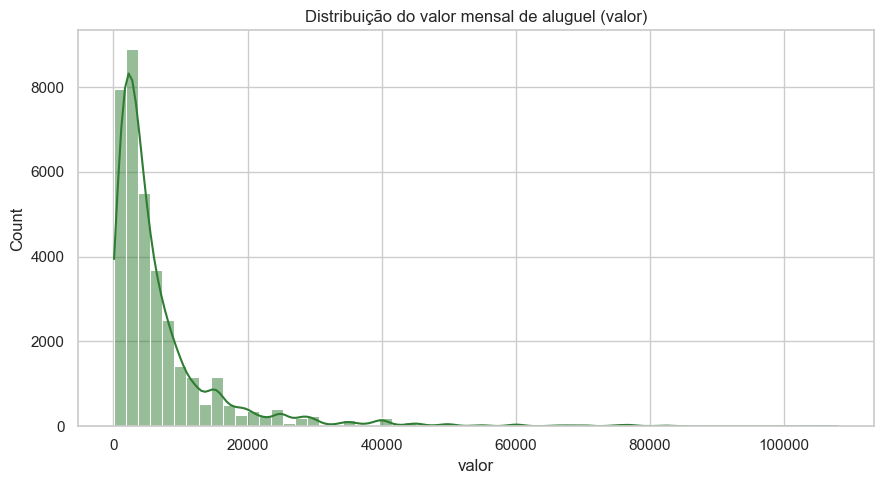

Assimetria (skew) de valor: 3.73
Mediana: R$ 4.000,00   |   Média: R$ 7.006,88


In [4]:
# Distribuição da variável-alvo (valor)
# Valores altos de aluguel podem puxar a média para cima, indicando assimetria à direita.
# Essa análise ajuda a avaliar se a métrica RMSE será sensível a valores extremos.
plot_histogram(df["valor"], "Distribuição do valor mensal de aluguel (valor)", "01_distribuicao_valor.png")

# Exibe a assimetria da variável-alvo
print(f"Assimetria (skew) de valor: {df['valor'].skew():.2f}")

print(
    f"Mediana: R$ {df['valor'].median():,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    + "   |   "
    + f"Média: R$ {df['valor'].mean():,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

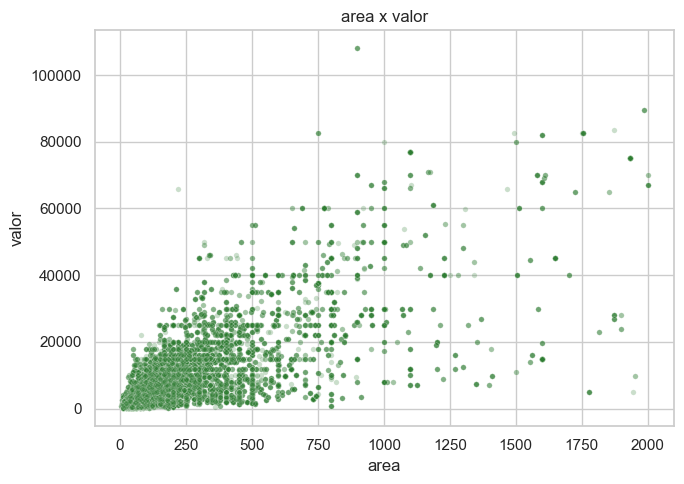

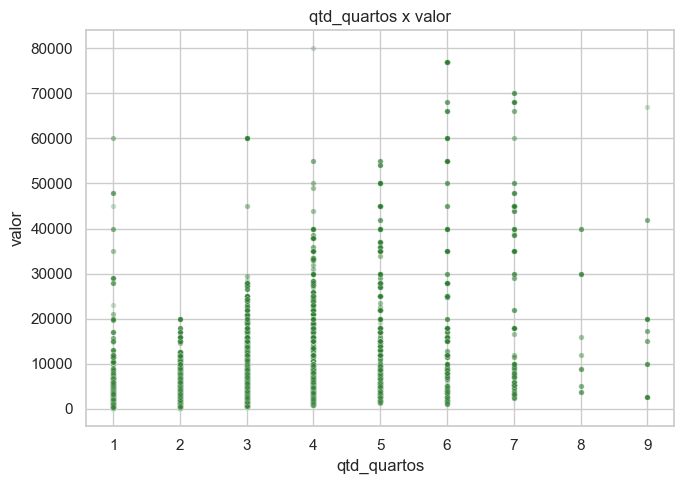

In [5]:
# Dispersão entre variáveis explicativas e a variável-alvo.
# Se houver uma relação crescente, esperamos ver os pontos formando
# uma "faixa" ao redor de uma reta crescente.

plot_scatter(df, x="area", y="valor", filename="02_scatter_area_valor.png")
plot_scatter(df, x="qtd_quartos", y="valor", filename="03_scatter_quartos_valor.png")

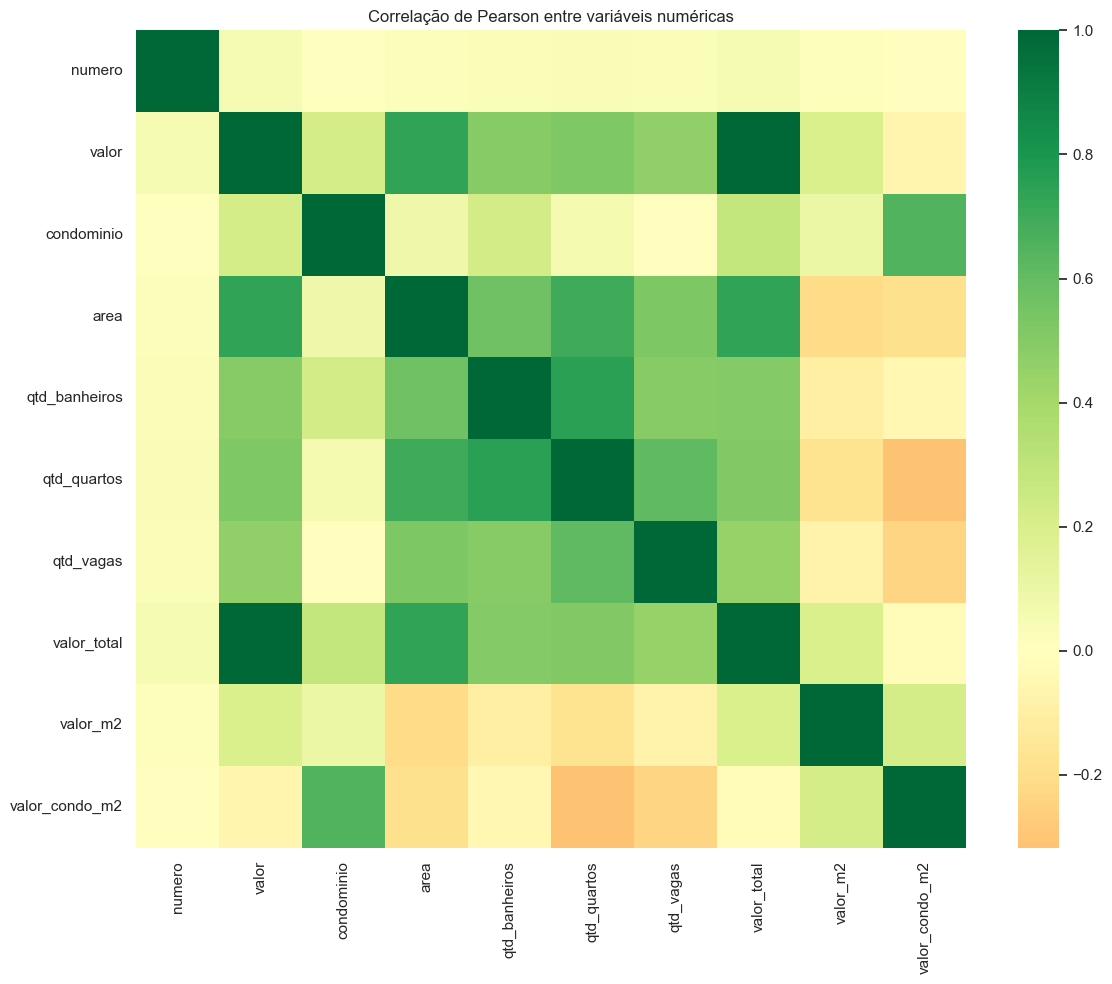

Pares com correlação > 0.7:
valor          valor_total   1.00
qtd_banheiros  qtd_quartos   0.75
valor          area          0.74
area           valor_total   0.74
dtype: float64


In [6]:
# Mapa de calor de correlação de Pearson entre as variáveis numéricas.
# Essa análise antecipa a Fase 4, pois variáveis muito correlacionadas entre si
# podem indicar multicolinearidade e exigir atenção antes da modelagem.

num_cols = df.select_dtypes(include=np.number).drop(columns=["Unnamed: 0", "id"], errors="ignore").columns

plot_correlation_heatmap(df[num_cols], filename="04_correlation_heatmap.png")

corr = df[num_cols].corr()

# Usamos correlação maior que 0.7 para identificar pares de variáveis muito relacionadas.
# Isso ajuda a decidir quais colunas precisam ser analisadas antes de treinar a Regressão Linear.
print("Pares com correlação > 0.7:")
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print(pairs[pairs.abs() > 0.7].sort_values(ascending=False))

**Análise crítica dos achados (Fase 1):**

- `valor` é fortemente assimétrica à direita (skew ≈ 3.73): a maioria dos imóveis se concentra em faixas menores de aluguel, mas um pequeno número de imóveis com valores muito altos puxa a média para cima. Isso indica que métricas como MAE e principalmente RMSE podem ser sensíveis a esses imóveis mais caros.

- `area` mostra relação crescente com `valor`, confirmando a hipótese de que imóveis maiores tendem a ter aluguéis mais altos. Mesmo assim, a dispersão dos pontos mostra que a área sozinha não explica totalmente o preço, pois imóveis com áreas semelhantes podem apresentar valores bastante diferentes.

- `qtd_quartos` também apresenta alguma relação com `valor`, mas de forma menos linear. Há grande variação de preço dentro da mesma quantidade de quartos, indicando que outras variáveis, como localização, tipo do imóvel, condomínio e padrão do imóvel, também influenciam o aluguel.

- O mapa de calor revela correlação forte entre `area` e `valor`, reforçando que `area` é uma variável candidata importante para o modelo. Também aparece correlação perfeita entre `valor` e `valor_total`, o que sugere vazamento de dados, já que `valor_total` parece derivar diretamente do aluguel. Por isso, `valor_total` não deve entrar como variável preditora.

- O mapa de calor também mostra correlação elevada entre `qtd_banheiros` e `qtd_quartos`, indicando possível multicolinearidade entre variáveis explicativas. Esse ponto deverá ser tratado na Fase 4 antes do treinamento da Regressão Linear.

- `bairro` não aparece no heatmap porque é uma variável categórica, mas a localização é relevante para o mercado imobiliário de Florianópolis. Por isso, ela será analisada separadamente e posteriormente transformada por encoding para entrar na modelagem.

## Fase 2 — Tratamento e Limpeza dos Dados (Data Prep)

Nesta etapa, serão avaliados problemas de qualidade da base, como duplicatas, valores ausentes e outliers.

Também será aplicado o recorte necessário para o problema preditivo deste projeto, mantendo apenas imóveis residenciais com aluguel mensal.

In [7]:
# --- Linhas duplicadas: duplicatas completas, com todas as colunas iguais ---
n_duplicatas = df.duplicated().sum()
print(f"Duplicatas completas encontradas: {n_duplicatas}")

# --- Duplicatas parciais: mesmo anúncio/imóvel aparecendo mais de uma vez pelo mesmo id ---
n_id_dup = df.duplicated(subset=["id"]).sum()
print(f"\nRegistros com 'id' repetido: {n_id_dup}")

# Exibe exemplos de anúncios repetidos para entender se são registros do mesmo imóvel ao longo do tempo
exemplo = df[df.duplicated(subset=["id"], keep=False)].sort_values("id")[["id", "data", "valor", "bairro", "tipo"]].head(6)

print("\nExemplo de anúncios com mesmo id:")
print(exemplo)

Duplicatas completas encontradas: 0

Registros com 'id' repetido: 26930

Exemplo de anúncios com mesmo id:
             id                        data  valor                    bairro  \
31485  62568647  2023-12-06 12:58:47.177954    650  Ingleses do Rio Vermelho   
24560  62568647  2023-12-05 00:49:56.388185    650  Ingleses do Rio Vermelho   
31586  62568665  2023-12-06 12:58:51.505844   1000  Ingleses do Rio Vermelho   
9864   62568665  2023-12-05 00:41:50.118292   1000  Ingleses do Rio Vermelho   
9829   62568665  2023-12-05 00:41:48.852946   1000  Ingleses do Rio Vermelho   
24785  62568665  2023-12-05 00:50:04.375044   1000  Ingleses do Rio Vermelho   

              tipo  
31485  Apartamento  
24560  Apartamento  
31586  Apartamento  
9864   Apartamento  
9829   Apartamento  
24785  Apartamento  


**Justificativa (duplicatas):** não foram encontradas duplicatas completas, ou seja, linhas 100% iguais em todas as colunas. No entanto, foram identificados muitos registros com `id` repetido, indicando que o mesmo anúncio aparece mais de uma vez em datas diferentes. Como o objetivo do projeto é modelar o valor de aluguel sem repetir excessivamente o mesmo imóvel, será mantido apenas o registro mais recente de cada `id`, usando a coluna `data` como referência.

In [8]:
# --- Valores ausentes ---
# Verifica quais colunas possuem valores nulos e quantos registros estão ausentes em cada uma delas.

print("Valores ausentes por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Calcula a assimetria das principais colunas numéricas com valores ausentes.
# Isso ajuda a decidir se a imputação deve ser feita por média ou mediana.

print(f"\nAssimetria (skew) de qtd_banheiros: {df['qtd_banheiros'].skew():.2f}")
print(f"Assimetria (skew) de qtd_quartos: {df['qtd_quartos'].skew():.2f}")
print(f"Assimetria (skew) de qtd_vagas: {df['qtd_vagas'].skew():.2f}")

Valores ausentes por coluna:
rua               9175
numero           18455
qtd_banheiros     2909
qtd_quartos      15125
qtd_vagas        10568
amenities         8491
dtype: int64

Assimetria (skew) de qtd_banheiros: 1.55
Assimetria (skew) de qtd_quartos: 0.94
Assimetria (skew) de qtd_vagas: 2.03


**Justificativa (valores ausentes):** foram identificados valores ausentes em colunas de localização (`rua`, `numero`), características do imóvel (`qtd_banheiros`, `qtd_quartos`, `qtd_vagas`) e comodidades (`amenities`). Para a modelagem, as colunas numéricas `qtd_banheiros`, `qtd_quartos` e `qtd_vagas` são relevantes e apresentam assimetria positiva. Por isso, a imputação será feita pela mediana, que é mais robusta à presença de imóveis com características muito acima do padrão. As colunas `rua`, `numero` e `amenities` não serão usadas diretamente como preditoras nesta primeira versão do modelo.

In [9]:
# Recarrega a base bruta para garantir que a limpeza seja aplicada sobre os dados originais
df = load_raw_data()

# Guarda o tamanho da base antes da limpeza
linhas_antes = df.shape[0]

# Aplica a limpeza inicial usando a função clean_data() definida em src/features.py
df = clean_data(df)

# Guarda o tamanho da base após a limpeza
linhas_depois = df.shape[0]

# Calcula quantas linhas foram removidas no processo
linhas_removidas = linhas_antes - linhas_depois

# Calcula o percentual de redução da base
percentual_reducao = (linhas_removidas / linhas_antes) * 100

print("Após aplicação da limpeza inicial:")

# Mostra o comparativo entre a base original e a base limpa
print(f"Linhas antes da limpeza: {linhas_antes:,}".replace(",", "."))
print(f"Linhas após a limpeza: {linhas_depois:,}".replace(",", "."))
print(f"Linhas removidas: {linhas_removidas:,}".replace(",", "."))
print(f"Redução da base: {percentual_reducao:.2f}%".replace(".", ","))

# Verifica se ainda existem duplicatas completas
print("Duplicatas completas restantes:", df.duplicated().sum())

# Verifica se ainda existem valores ausentes na base
print("Valores ausentes restantes:", df.isnull().sum().sum())

# Mostra o novo tamanho da base após filtros e remoção de ids repetidos
print(f"Shape após limpeza: {df.shape}")

Após aplicação da limpeza inicial:
Linhas antes da limpeza: 36.092
Linhas após a limpeza: 4.454
Linhas removidas: 31.638
Redução da base: 87,66%
Duplicatas completas restantes: 0
Valores ausentes restantes: 3482
Shape após limpeza: (4454, 24)


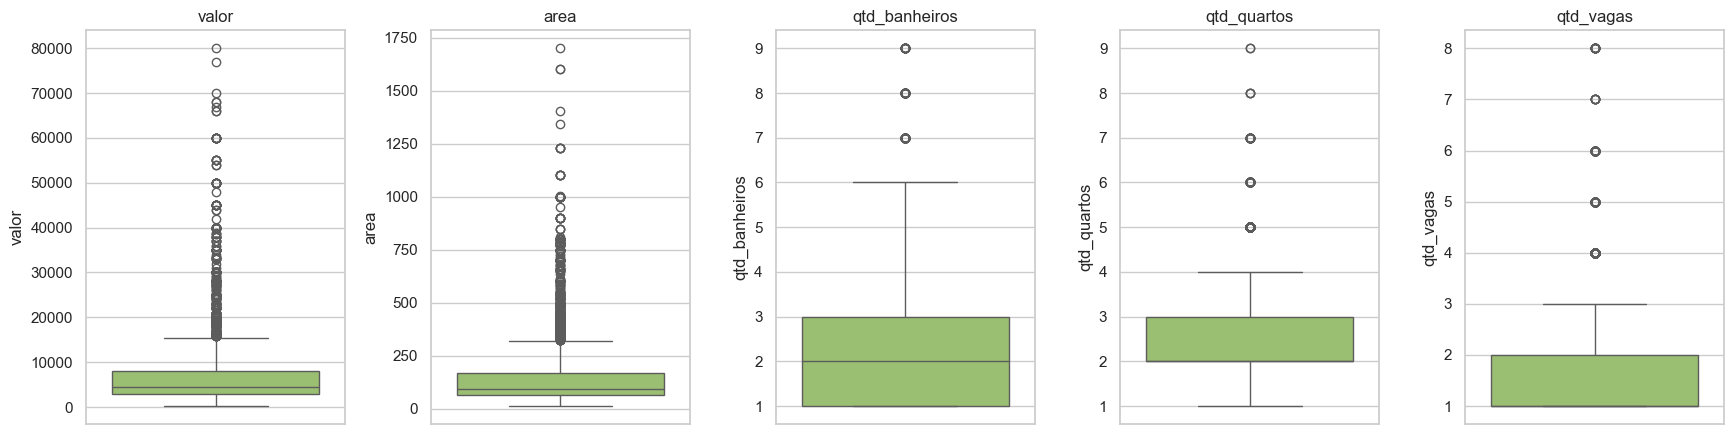

Imóveis com maiores valores de aluguel:
              id                       data                 bairro  tipo  \
888   2490415791 2023-12-05 00:46:21.684098   Jurerê Internacional  Casa   
957   2658193377 2023-12-05 00:47:26.455126   Jurerê Internacional  Casa   
3780  2640060121 2023-12-06 13:00:28.336659   Jurerê Internacional  Casa   
4245  2490752515 2023-12-06 13:00:53.534052   Jurerê Internacional  Casa   
2436  2490708676 2023-12-06 12:58:36.677111   Jurerê Internacional  Casa   

      valor     area  qtd_banheiros  qtd_quartos  qtd_vagas  
888   80000 1,000.00           5.00         4.00       5.00  
957   77000 1,100.00           9.00         6.00       4.00  
3780  70000 1,100.00           1.00         7.00       4.00  
4245  68000 1,600.00           9.00         7.00       4.00  
2436  68000 1,000.00           8.00         6.00       8.00  


In [10]:
# --- Detecção de outliers com boxplots ---
# Os boxplots ajudam a visualizar valores muito distantes do padrão da base.

plot_boxplots(
    df,
    ["valor", "area", "qtd_banheiros", "qtd_quartos", "qtd_vagas"],
    filename="05_boxplots_outliers.png"
)

# Exibe os imóveis com maiores valores de aluguel para inspeção inicial
print("Imóveis com maiores valores de aluguel:")
print(
    df.sort_values("valor", ascending=False)[
        ["id", "data", "bairro", "tipo", "valor", "area", "qtd_banheiros", "qtd_quartos", "qtd_vagas"]
    ].head(5)
)

In [11]:
# Verifica quais tipos de imóveis permaneceram após o filtro de Residencial + Mês
# Essa análise ajuda a identificar possíveis inconsistências na classificação da base

print("Tipos de imóveis após a limpeza inicial:")
print(df["tipo"].value_counts())

Tipos de imóveis após a limpeza inicial:
tipo
Apartamento              2964
Casa                     1410
Kitnet/Conjugado           58
Loft                       13
Flat                        8
Fazenda/Sítio/Chácara       1
Name: count, dtype: int64


**Justificativa (outliers e recorte residencial):** após o filtro inicial por `categoria` igual a residencial e `periodicidade` igual a mês, ainda foram identificados tipos de imóveis com perfil comercial ou genérico, como `Sala/Conjunto`, `Galpão/Depósito/Armazém`, `Lote/Terreno` e `Prédio/Edifício`. Por isso, a função `clean_data()` foi ajustada para manter apenas tipos compatíveis com o problema preditivo de aluguel residencial, como `Apartamento`, `Casa`, `Kitnet/Conjugado`, `Loft`, `Flat` e `Fazenda/Sítio/Chácara`.

Esse ajuste reduziu a base de 7.138 para 4.454 registros após a limpeza, mas tornou o dataset mais coerente com o objetivo do projeto. Os maiores valores restantes passaram a representar principalmente casas em bairros de alto padrão, como Jurerê Internacional, o que é plausível para o mercado imobiliário de Florianópolis.

Os boxplots ainda indicam presença de outliers em `valor`, `area`, `qtd_banheiros`, `qtd_quartos` e `qtd_vagas`. No entanto, esses pontos não serão removidos automaticamente, pois podem representar imóveis residenciais de alto padrão, e não necessariamente erros de coleta. Remover esses registros poderia fazer o modelo subestimar imóveis mais caros, justamente a faixa em que erros de previsão têm maior impacto financeiro.

Na próxima etapa, os outliers serão tratados com cautela. Variáveis estruturais como `qtd_quartos`, `qtd_banheiros` e `qtd_vagas` poderão receber contenção por IQR quando apresentarem valores muito fora do padrão, enquanto `valor` e `area` serão analisados com cuidado para evitar a exclusão indevida de imóveis residenciais legítimos de alto valor.

In [12]:
# --- Avaliação dos outliers por IQR ---
# O método IQR identifica valores abaixo de Q1 - 1.5*IQR ou acima de Q3 + 1.5*IQR.
# Neste projeto, os outliers serão analisados antes de qualquer remoção automática,
# pois imóveis de alto padrão podem ser registros válidos no mercado de Florianópolis.

colunas_outliers = ["valor", "area", "qtd_banheiros", "qtd_quartos", "qtd_vagas"]

for coluna in colunas_outliers:
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1

    #limite_inf = q1 - 1.5 * iqr
    limite_inf = max(0, q1 - 1.5 * iqr)
    limite_sup = q3 + 1.5 * iqr

    outliers = ((df[coluna] < limite_inf) | (df[coluna] > limite_sup)).sum()

    print(f"Tratamento de outliers em '{coluna}':")
    print(f"limite=[{limite_inf:.2f}, {limite_sup:.2f}] | outliers identificados={outliers}")
    print("-" * 60)

# Nesta versão, os outliers não serão removidos automaticamente.
# A decisão é manter os registros por representarem possíveis imóveis residenciais de alto padrão.

Tratamento de outliers em 'valor':
limite=[0.00, 15515.00] | outliers identificados=450
------------------------------------------------------------
Tratamento de outliers em 'area':
limite=[0.00, 320.50] | outliers identificados=459
------------------------------------------------------------
Tratamento de outliers em 'qtd_banheiros':
limite=[0.00, 6.00] | outliers identificados=121
------------------------------------------------------------
Tratamento de outliers em 'qtd_quartos':
limite=[0.50, 4.50] | outliers identificados=301
------------------------------------------------------------
Tratamento de outliers em 'qtd_vagas':
limite=[0.00, 3.50] | outliers identificados=397
------------------------------------------------------------


**Justificativa (tratamento de outliers):** o método IQR identificou outliers em `valor`, `area`, `qtd_banheiros`, `qtd_quartos` e `qtd_vagas`. No entanto, após o recorte para imóveis residenciais, os maiores valores observados correspondem principalmente a casas em bairros de alto padrão, como Jurerê Internacional. Por isso, esses registros não serão removidos automaticamente nesta etapa, pois podem representar imóveis válidos do mercado imobiliário de Florianópolis. A remoção indiscriminada poderia levar o modelo a subestimar imóveis de maior valor.

In [13]:
# Verifica quais colunas ainda possuem valores ausentes após a limpeza inicial
# Essa checagem confirma se os nulos restantes estão em colunas que não serão usadas na modelagem

print("Valores ausentes restantes por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Valores ausentes restantes por coluna:
rua           983
numero       1985
amenities     514
dtype: int64


**Justificativa (valores ausentes restantes):** após a limpeza inicial, os valores ausentes restantes estão concentrados nas colunas `rua`, `numero` e `amenities`. Essas variáveis não serão utilizadas diretamente como preditoras na primeira versão do modelo, pois `rua` e `numero` possuem alta granularidade e podem tornar o modelo muito específico, enquanto `amenities` exige tratamento textual mais complexo. Por isso, os nulos restantes foram mantidos nesta etapa sem prejudicar a modelagem inicial.

## Fase 3 — Feature Engineering (Coluna Calculada)

Nesta etapa, serão criadas novas variáveis a partir das colunas existentes.

O objetivo é enriquecer a base com informações derivadas que possam ajudar o modelo a compreender melhor as características dos imóveis e sua relação com o valor do aluguel.

In [14]:
# add_features() cria colunas derivadas a partir das variáveis já existentes.
# area_por_quarto: área média disponível por quarto.
# tem_vaga: indicador lógico que mostra se o imóvel possui pelo menos uma vaga.
# Essas variáveis podem ajudar o modelo a capturar características adicionais do imóvel.

df = add_features(df)

print(df[["area", "qtd_quartos", "area_por_quarto", "qtd_vagas", "tem_vaga"]].head())

    area  qtd_quartos  area_por_quarto  qtd_vagas  tem_vaga
0  55.00         2.00            27.50       1.00         1
1  70.00         2.00            35.00       1.00         1
2 110.00         3.00            36.67       1.00         1
3 123.00         3.00            41.00       1.00         1
4  54.00         2.00            27.00       1.00         1


In [15]:
# Salva o dataframe já limpo da Fase 2 e com as features derivadas da Fase 3.
# Isso permite retomar o pipeline a partir da base processada,
# sem precisar reprocessar o dataset bruto desde o início.

save_processed_data(df)

Dataset processado salvo em: C:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\Desenvolvimento de IA para Análise Preditiva [T2]\IA\PRojeto Final-M1\alugaFloripa\data\processed\aluguel_floripa_processed.csv


## Fase 4 — Preparação para Modelagem

Nesta etapa, a base será preparada para o treinamento dos modelos.

Serão selecionadas as variáveis explicativas e a variável-alvo, aplicadas as transformações necessárias em variáveis categóricas, avaliada a multicolinearidade, realizada a divisão entre treino e teste e aplicado o escalonamento das variáveis.

In [16]:
# Carrega a base processada, já limpa e com as features derivadas das Fases 2 e 3.
# Isso permite iniciar a preparação para modelagem sem reprocessar o dataset bruto.

df = load_processed_data()

print(f"Shape da base processada: {df.shape}")
df.head()

Shape da base processada: (4454, 26)


,Unnamed: 0,data,fonte,id,descricao,tipo,endereco,rua,numero,bairro,cidade,valor,periodicidade,condominio,area,qtd_banheiros,qtd_quartos,qtd_vagas,url,amenities,categoria,valor_total,valor_m2,valor_condo_m2,area_por_quarto,tem_vaga
0,7,2023-12-05 00:35:45.817365,Vivareal,2666963712,"Apartamento com 2 Quartos para Aluguel, 55m²",Apartamento,"Rodovia Baldicero Filomeno - Ribeirão da Ilha,...",Rodovia Baldicero Filomeno,NaN,Ribeirão da Ilha,florianopolis,2100,Mês,599.00,55.00,1.00,2.00,1.00,https://vivareal.com.br/imovel/apartamento-2-q...,Playground; Interfone; Área de serviço,Residencial,"2,699.00",38.18,10.89,27.50,1
1,9,2023-12-05 00:35:45.819841,Vivareal,2666916709,"Apartamento com 2 Quartos para Aluguel, 70m²",Apartamento,"Rua Coronel Luiz Caldeira, 149 - Itacorubi, Fl...",Rua Coronel Luiz Caldeira,149.00,Itacorubi,florianopolis,3700,Mês,550.00,70.00,3.00,2.00,1.00,https://vivareal.com.br/imovel/apartamento-2-q...,Garagem,Residencial,"4,250.00",52.86,7.86,35.00,1
2,20,2023-12-05 00:35:45.833724,Vivareal,2664501915,"Apartamento com 3 Quartos para Aluguel, 110m²",Apartamento,"Rua Lauro Linhares, 1520 - Trindade, Florianóp...",Rua Lauro Linhares,"1,520.00",Trindade,florianopolis,2900,Mês,750.00,110.00,2.00,3.00,1.00,https://vivareal.com.br/imovel/apartamento-3-q...,Elevador; Condomínio fechado; Varanda; Varanda...,Residencial,"3,650.00",26.36,6.82,36.67,1
3,28,2023-12-05 00:35:45.843232,Vivareal,2666987898,"Apartamento com 3 Quartos para Aluguel, 123m²",Apartamento,"Balneario do Estreito, Florianópolis - SC",NaN,NaN,Balneario do Estreito,florianopolis,3650,Mês,950.00,123.00,3.00,3.00,1.00,https://vivareal.com.br/imovel/apartamento-3-q...,Ar-condicionado; Elevador; Vista para o mar; S...,Residencial,"4,600.00",29.67,7.72,41.00,1
4,29,2023-12-05 00:35:45.844950,Vivareal,2666217695,"Apartamento com 2 Quartos para Aluguel, 54m²",Apartamento,"Rua das Tainhotas, 133 - Jurerê, Florianópolis...",Rua das Tainhotas,133.00,Jurerê,florianopolis,2900,Mês,550.00,54.00,1.00,2.00,1.00,https://vivareal.com.br/imovel/apartamento-2-q...,NaN,Residencial,"3,450.00",53.70,10.19,27.00,1


In [17]:
# Seleciona as variáveis explicativas que serão usadas na modelagem.
# Não usamos id, data, url, descricao, endereco, rua, numero, amenities, valor_total, valor_m2 e valor_condo_m2.
# valor_total, valor_m2 e valor_condo_m2 não entram porque derivam do valor do aluguel e podem causar vazamento de dados.

explicativas = [
    "tipo",
    "bairro",
    "condominio",
    "area",
    "qtd_banheiros",
    "qtd_quartos",
    "qtd_vagas",
    "area_por_quarto",
    "tem_vaga",
]

X = df[explicativas].copy()
y = df["valor"].copy()

print("Variáveis explicativas selecionadas:")
print(explicativas)

print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

Variáveis explicativas selecionadas:
['tipo', 'bairro', 'condominio', 'area', 'qtd_banheiros', 'qtd_quartos', 'qtd_vagas', 'area_por_quarto', 'tem_vaga']

Shape de X: (4454, 9)
Shape de y: (4454,)


In [18]:
# Divide a base em treino e teste.
# 80% dos dados serão usados para treinar o modelo e 20% para testar sua capacidade de generalização.

X_train, X_test, y_train, y_test = train_test_split(
    X,  # Variáveis explicativas
    y,  # Variável-alvo
    test_size=TEST_SIZE,  # Percentual reservado para teste, definido em src/config.py
    random_state=RANDOM_STATE  # Garante reprodutibilidade da divisão
)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treino: (3563, 9)
Teste: (891, 9)


In [19]:
# Aplica One-Hot Encoding nas variáveis categóricas tipo e bairro.
# Isso transforma categorias textuais em colunas numéricas 0/1 para o modelo conseguir interpretar.

X_train_encoded = pd.get_dummies(
    X_train,  # Dados de treino
    columns=["tipo", "bairro"],  # Colunas categóricas que serão transformadas
    drop_first=True  # Remove a primeira categoria para evitar redundância
)

X_test_encoded = pd.get_dummies(
    X_test,  # Dados de teste
    columns=["tipo", "bairro"],  # Mesmas colunas categóricas usadas no treino
    drop_first=True  # Remove a primeira categoria para evitar redundância
)

# Garante que treino e teste tenham exatamente as mesmas colunas após o encoding
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"Treino após encoding: {X_train_encoded.shape}")
print(f"Teste após encoding: {X_test_encoded.shape}")

Treino após encoding: (3563, 130)
Teste após encoding: (891, 130)


In [20]:
# Salva o recorte final da base usado na modelagem.
# Este arquivo contém apenas as variáveis explicativas selecionadas e a variável-alvo.
# Não inclui colunas removidas por vazamento de dados, como valor_total, valor_m2 e valor_condo_m2.

df_final = select_final_columns(df, explicativas, "valor")

save_final_data(df_final)

print(f"Shape da base final para modelagem: {df_final.shape}")
df_final.head()

Dataset final salvo em: C:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\Desenvolvimento de IA para Análise Preditiva [T2]\IA\PRojeto Final-M1\alugaFloripa\data\final\aluguel_floripa_final.csv
Shape da base final para modelagem: (4454, 10)


,tipo,bairro,condominio,area,qtd_banheiros,qtd_quartos,qtd_vagas,area_por_quarto,tem_vaga,valor
0,Apartamento,Ribeirão da Ilha,599.00,55.00,1.00,2.00,1.00,27.50,1,2100
1,Apartamento,Itacorubi,550.00,70.00,3.00,2.00,1.00,35.00,1,3700
2,Apartamento,Trindade,750.00,110.00,2.00,3.00,1.00,36.67,1,2900
3,Apartamento,Balneario do Estreito,950.00,123.00,3.00,3.00,1.00,41.00,1,3650
4,Apartamento,Jurerê,550.00,54.00,1.00,2.00,1.00,27.00,1,2900


In [21]:
# Correlação entre as próprias variáveis explicativas, sem considerar o alvo.
# Essa análise ajuda a localizar pares de variáveis muito correlacionadas antes de calcular o VIF.

corr_x = X_train_encoded.corr(numeric_only=True)

pares_redundantes = corr_x.where(
    np.triu(np.ones(corr_x.shape), k=1).astype(bool)
).stack()

print("Pares de variáveis explicativas com correlação > 0.7:")
print(pares_redundantes[pares_redundantes.abs() > 0.7].sort_values(ascending=False))

Pares de variáveis explicativas com correlação > 0.7:
area           area_por_quarto   0.80
               qtd_banheiros     0.72
               qtd_quartos       0.72
qtd_banheiros  qtd_quartos       0.71
dtype: float64


`area` está fortemente correlacionada com `area_por_quarto` (0.80), o que faz sentido, pois `area_por_quarto` foi criada a partir da própria área do imóvel dividida pela quantidade de quartos. Também há correlação relevante entre `area`, `qtd_banheiros` e `qtd_quartos`, indicando que imóveis maiores tendem a ter mais cômodos.

Manter `area` e `area_por_quarto` juntas pode inflar artificialmente o VIF, pois ambas carregam parte da mesma informação. Por isso, `area_por_quarto` será removida antes do cálculo do VIF e da modelagem, mantendo `area`, `qtd_quartos`, `qtd_banheiros`, `qtd_vagas` e `tem_vaga` como características estruturais principais do imóvel.

In [22]:
# Define a lista de colunas que serão removidas antes do cálculo do VIF
# A coluna area_por_quarto será removida porque foi criada a partir da própria coluna area
# e apresentou correlação alta com ela, podendo gerar redundância no modelo
colunas_redundantes = ["area_por_quarto"]

# Remove a coluna redundante da base de treino já codificada
# astype(float) garante que todas as colunas estejam em formato numérico para o cálculo do VIF
X_train_model = X_train_encoded.drop(columns=colunas_redundantes).astype(float)

# Remove a mesma coluna redundante da base de teste já codificada
# É importante que treino e teste tenham as mesmas colunas
X_test_model = X_test_encoded.drop(columns=colunas_redundantes).astype(float)

# Adiciona uma constante ao conjunto de treino
# O VIF precisa dessa constante para calcular corretamente a regressão auxiliar de cada variável
X_vif = sm.add_constant(X_train_model, has_constant="add")

# Calcula o VIF de cada variável explicativa
# variance_inflation_factor mede quanto a variância de uma variável é inflada pela correlação com as outras
vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
    index=X_vif.columns
)

# Remove a constante da lista final de VIF, porque ela não é uma variável explicativa real do modelo
# errors="ignore" evita erro caso a coluna const não exista por algum motivo
vif = vif.drop("const", errors="ignore")

# Exibe os maiores valores de VIF
# Valores acima de 10 indicam multicolinearidade relevante
print("VIF por variável — valores acima de 10 indicam multicolinearidade relevante:")
print(vif.sort_values(ascending=False).head(20))

c:\Users\crisj\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


VIF por variável — valores acima de 10 indicam multicolinearidade relevante:
bairro_ Centro                     8.25
bairro_ Campeche                   5.58
area                               3.58
bairro_ Agronômica                 3.51
bairro_ Jurerê Internacional       3.36
bairro_ Itacorubi                  3.33
bairro_ Trindade                   3.20
tipo_Casa                          3.07
qtd_quartos                        2.95
qtd_banheiros                      2.85
bairro_ Ingleses do Rio Vermelho   2.84
bairro_Centro                      2.84
bairro_ Carvoeira                  2.65
bairro_ Estreito                   2.51
bairro_ Rio Tavares                2.42
bairro_ Coqueiros                  2.29
bairro_Campeche                    2.23
bairro_ Lagoa da Conceição         2.21
bairro_ Capoeiras                  2.12
bairro_Jurerê Internacional        2.09
dtype: float64


**Justificativa (VIF):** após a remoção de `area_por_quarto`, os valores de VIF ficaram abaixo de 10. O maior valor observado foi em `bairro_Centro` (8.25), indicando atenção, mas não multicolinearidade severa. Como a localização é uma variável relevante para a formação do preço de aluguel em Florianópolis, as variáveis de bairro foram mantidas no modelo.

In [23]:
# Escalonamento das variáveis explicativas.
# A Regressão Linear até funciona sem escala, mas o escalonamento ajuda a comparar variáveis
# que estão em magnitudes diferentes, como area, condominio e colunas 0/1 de bairro.

scaler = StandardScaler()  # Cria o padronizador

X_train_scaled = scaler.fit_transform(X_train_model)  # Ajusta o scaler no treino e transforma o treino
X_test_scaled = scaler.transform(X_test_model)  # Usa o mesmo scaler do treino para transformar o teste

print("Total de variáveis explicativas/features utilizadas no modelo:", X_train_model.shape[1])
print(list(X_train_model.columns))

Total de variáveis explicativas/features utilizadas no modelo: 129
['condominio', 'area', 'qtd_banheiros', 'qtd_quartos', 'qtd_vagas', 'tem_vaga', 'tipo_Casa', 'tipo_Flat', 'tipo_Kitnet/Conjugado', 'tipo_Loft', 'bairro_ Agronômica', 'bairro_ Alto Ribeirão', 'bairro_ Armação', 'bairro_ Armação do Pântano do Sul', 'bairro_ Açores', 'bairro_ Balneario do Estreito', 'bairro_ Balneário', 'bairro_ Barra da Lagoa', 'bairro_ Beira Mar', 'bairro_ Bom Abrigo', 'bairro_ Cachoeira do Bom Jesus', 'bairro_ Cacupé', 'bairro_ Campeche', 'bairro_ Canajure', 'bairro_ Canasvieiras', 'bairro_ Canto', 'bairro_ Canto da Lagoa', 'bairro_ Capoeiras', 'bairro_ Carianos', 'bairro_ Carvoeira', 'bairro_ Centro', 'bairro_ Coloninha', 'bairro_ Coqueiros', 'bairro_ Costeira do Pirajubaé', 'bairro_ Córrego Grande', 'bairro_ Daniela', 'bairro_ Estreito', 'bairro_ Ingleses Norte', 'bairro_ Ingleses do Rio Vermelho', 'bairro_ Itacorubi', 'bairro_ Itaguaçu', 'bairro_ Jardim Atlântico', 'bairro_ Joao Paulo', 'bairro_ José

## Fase 5 — Modelagem, Validação e Diagnóstico de Overfitting

Nesta etapa, será treinado o modelo base de Regressão Linear.

O desempenho será comparado entre treino e teste para avaliar se o modelo apresenta sinais de overfitting ou se consegue generalizar bem para dados novos.

In [24]:
# Cria o modelo base de Regressão Linear
modelo_lr = LinearRegression()

# Treina o modelo usando as variáveis explicativas escalonadas do conjunto de treino
modelo_lr.fit(X_train_scaled, y_train)

# Gera previsões para os próprios dados de treino
# Isso permite avaliar o desempenho do modelo nos dados que ele já viu
y_pred_train = modelo_lr.predict(X_train_scaled)

# Gera previsões para os dados de teste
# Isso permite avaliar se o modelo generaliza bem para dados novos
y_pred_test = modelo_lr.predict(X_test_scaled)

# Calcula o erro absoluto médio no treino
mae_train = mean_absolute_error(y_train, y_pred_train)

# Calcula o erro quadrático médio no treino
mse_train = mean_squared_error(y_train, y_pred_train)

# Calcula a raiz do erro quadrático médio no treino
rmse_train = np.sqrt(mse_train)

# Calcula o R² no treino
r2_train = r2_score(y_train, y_pred_train)

# Calcula o erro absoluto médio no teste
mae_test = mean_absolute_error(y_test, y_pred_test)

# Calcula o erro quadrático médio no teste
mse_test = mean_squared_error(y_test, y_pred_test)

# Calcula a raiz do erro quadrático médio no teste
rmse_test = np.sqrt(mse_test)

# Calcula o R² no teste
r2_test = r2_score(y_test, y_pred_test)

# Exibe as métricas do conjunto de treino
print("Regressão Linear — TREINO")
print(f"MAE: R$ {mae_train:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"MSE: {mse_train:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"RMSE: R$ {rmse_train:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"R²: {r2_train:.4f}")

# Exibe as métricas do conjunto de teste
print("\nRegressão Linear — TESTE")
print(f"MAE: R$ {mae_test:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"MSE: {mse_test:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"RMSE: R$ {rmse_test:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"R²: {r2_test:.4f}")

Regressão Linear — TREINO
MAE: R$ 2.198,12
MSE: 15.293.280,25
RMSE: R$ 3.910,66
R²: 0.7770

Regressão Linear — TESTE
MAE: R$ 2.403,63
MSE: 19.980.462,43
RMSE: R$ 4.469,95
R²: 0.7489


**Diagnóstico de overfitting:** o MAE de treino foi de R$ 2.198,12 e o MAE de teste foi de R$ 2.403,63. O RMSE de treino foi de R$ 3.910,66 e o RMSE de teste foi de R$ 4.469,95. Já o R² ficou em 0.7770 no treino e 0.7489 no teste. Como as métricas de treino e teste ficaram próximas, não há evidência forte de overfitting. O modelo apresenta queda moderada no teste, mas ainda consegue generalizar para dados novos com desempenho semelhante ao observado no treino.

**Nota (diferencial opcional):** como etapa extra, poderia ser treinado um segundo algoritmo de regressão, como `KNeighborsRegressor`, `DecisionTreeRegressor` ou `RandomForestRegressor`, para comparar o desempenho com a Regressão Linear. Nesta versão do projeto, o modelo base escolhido e versionado será a Regressão Linear, mantendo o foco na interpretação das métricas e no cumprimento dos requisitos obrigatórios.

## Fase 6 — Avaliação, Interpretação e Versionamento do Modelo

Nesta etapa, serão avaliados os resultados finais do modelo no conjunto de teste, gerados gráficos analíticos para interpretação dos erros e salvos os arquivos versionados do modelo e das métricas.

In [25]:
# Define a Regressão Linear como modelo para essa versão do projeto
modelo_campeao = modelo_lr

# Define o nome do modelo campeão para registro das métricas
nome_campeao = "Regressão Linear"

# Organiza as métricas finais do conjunto de teste em um dicionário
metricas_teste = {
    "MAE": mae_test,
    "MSE": mse_test,
    "RMSE": rmse_test,
    "R2": r2_test
}

# Exibe o modelo salvo como campeão
print(f"Modelo salvo como v1: {nome_campeao}")

# Exibe as métricas finais do teste
print("Métricas finais no conjunto de teste:")
print(f"MAE: R$ {metricas_teste['MAE']:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"MSE: {metricas_teste['MSE']:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"RMSE: R$ {metricas_teste['RMSE']:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"R²: {metricas_teste['R2']:.4f}")

Modelo salvo como v1: Regressão Linear
Métricas finais no conjunto de teste:
MAE: R$ 2.403,63
MSE: 19.980.462,43
RMSE: R$ 4.469,95
R²: 0.7489


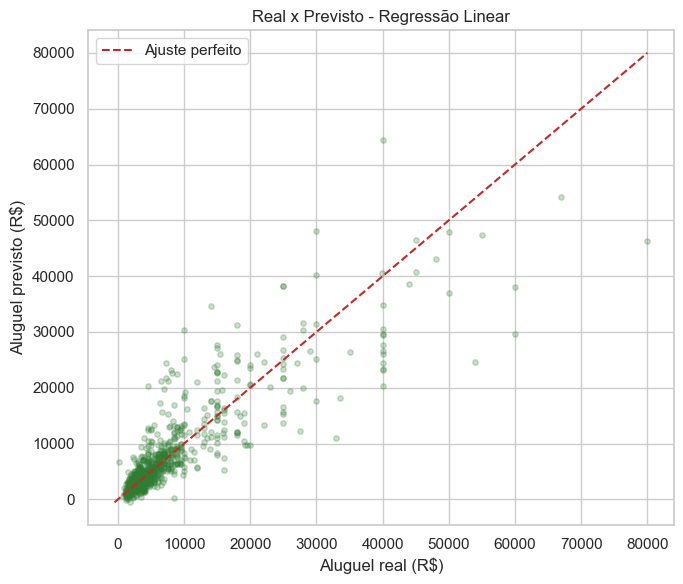

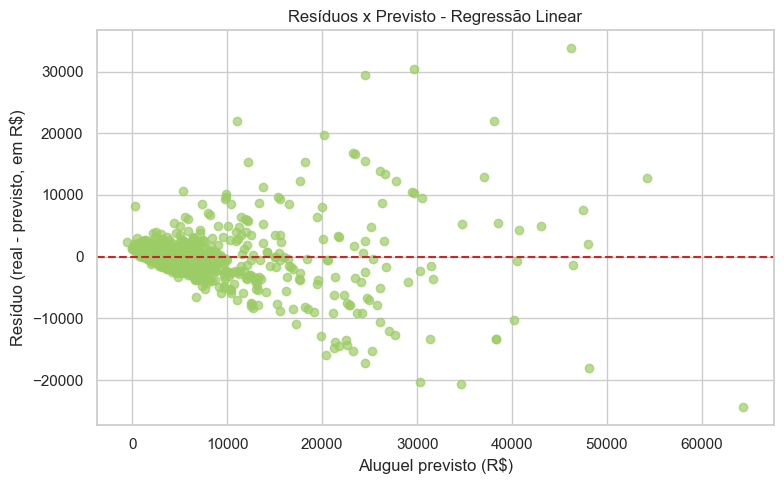

Resíduo médio: R$ -111,78
Desvio padrão dos resíduos: R$ 4.471,06


In [26]:
# Gráfico 1: compara os valores reais com os valores previstos pelo modelo
# Quanto mais próximos os pontos estiverem da linha vermelha, melhor está a previsão

plot_observed_vs_predicted(
    y_test,
    y_pred_test,
    "Real x Previsto - Regressão Linear",
    "06_real_vs_previsto.png"
)

# Calcula os resíduos do modelo
# Resíduo = valor real - valor previsto
residuos = y_test - y_pred_test

# Gráfico 2: mostra os resíduos em relação aos valores previstos
# O ideal é que os pontos fiquem espalhados ao redor da linha zero, sem padrão muito forte

plot_residuals(
    y_test,
    y_pred_test,
    "Resíduos x Previsto - Regressão Linear",
    "07_residuos_previsto.png"
)

# Exibe estatísticas simples dos resíduos
print(f"Resíduo médio: R$ {residuos.mean():,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"Desvio padrão dos resíduos: R$ {residuos.std():,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))

**Veredito de negócio:** em média, o modelo erra cerca de R$ 2.403,63 na estimativa do aluguel mensal de um imóvel residencial em Florianópolis, considerando o MAE do conjunto de teste. Esse valor representa o erro médio absoluto esperado para imóveis que o modelo ainda não viu.

O RMSE de teste foi de R$ 4.469,95, valor mais alto que o MAE. Essa diferença indica que existem alguns casos com erros maiores, principalmente imóveis de maior valor ou fora do padrão, que puxam o RMSE para cima. Isso é coerente com os gráficos: nos imóveis de aluguel mais baixo e intermediário, os pontos ficam mais próximos da linha de ajuste perfeito; já nos imóveis mais caros, os erros ficam mais espalhados.

Essa margem de erro não deve ser usada sozinha para definir o preço final de um aluguel, mas pode servir como uma primeira estimativa de referência para comparar imóveis semelhantes. Na prática, o modelo pode ajudar proprietários, imobiliárias e locatários a identificar se um valor anunciado está muito acima ou abaixo do esperado para imóveis com características parecidas.

Como melhoria futura, seria interessante incluir novas variáveis que influenciam fortemente o aluguel em Florianópolis, como proximidade da praia, mobília, vista, padrão do condomínio, estado de conservação e distância de serviços. Também poderia ser testado um modelo não linear, como Random Forest ou KNN Regressor, para verificar se ele captura melhor os imóveis de alto padrão.

## Fase 6a — Retreino do Modelo Final com 100% dos Dados

Após avaliar o desempenho do modelo com a divisão treino/teste, o modelo final será retreinado utilizando 100% da base disponível.

As métricas reportadas continuam sendo as métricas do conjunto de teste, pois elas representam a avaliação honesta em dados não vistos. O retreino com todos os dados serve apenas para gerar o artefato final versionado do modelo.

In [27]:
# Seleciona novamente as variáveis explicativas na base completa
# Aqui usamos toda a base disponível, sem separar treino e teste
X_full = df[explicativas].copy()

# Seleciona novamente a variável-alvo na base completa
y_full = df["valor"].copy()

# Aplica One-Hot Encoding nas variáveis categóricas da base completa
# Mantemos o mesmo tratamento usado na Fase 4 para tipo e bairro
X_full_encoded = pd.get_dummies(
    X_full,
    columns=["tipo", "bairro"],
    drop_first=True
)

# Remove a mesma coluna redundante removida antes do VIF e da modelagem
# Isso mantém coerência com o modelo avaliado anteriormente
X_full_encoded = X_full_encoded.drop(columns=colunas_redundantes, errors="ignore")

# Garante que a base completa tenha exatamente as mesmas colunas usadas no treino do modelo avaliado
# Caso alguma coluna esteja ausente, ela será preenchida com zero
X_full_encoded = X_full_encoded.reindex(columns=X_train_model.columns, fill_value=0)

# Converte todas as colunas para float, garantindo compatibilidade com o scaler e a Regressão Linear
X_full_encoded = X_full_encoded.astype(float)

# Cria um novo StandardScaler para o modelo final
# Esse scaler será ajustado com 100% dos dados disponíveis
scaler_final = StandardScaler()

# Ajusta o scaler na base completa e transforma os dados
X_full_scaled = scaler_final.fit_transform(X_full_encoded)

# Cria o modelo final de Regressão Linear
modelo_final = LinearRegression()

# Treina o modelo final usando 100% da base disponível
modelo_final.fit(X_full_scaled, y_full)

# Exibe a quantidade de registros usados no retreino final
print(f"Modelo final retreinado com {X_full.shape[0]} imóveis usando 100% da base disponível.")

Modelo final retreinado com 4454 imóveis usando 100% da base disponível.


In [28]:
# Cria um dicionário com o modelo final, o scaler final e as colunas usadas na modelagem
# Isso permite reutilizar o modelo depois com a mesma estrutura de preparação dos dados
artefato_modelo = {
    "modelo": modelo_final,
    "scaler": scaler_final,
    "colunas_modelo": X_full_encoded.columns.tolist()
}

# Cria um dicionário com as informações e métricas da versão v1 do modelo
metricas_v1 = {
    "versao": "v1",
    "modelo_salvo": "Regressão Linear",
    "data_treinamento": datetime.now().strftime("%Y-%m-%d"),
    "treinado_com": "100% da base disponível após avaliação com split treino/teste",
    "features_utilizadas": X_full_encoded.columns.tolist(),
    "observacao": "As métricas reportadas são do conjunto de teste da Fase 5, pois representam a avaliação honesta em dados não vistos.",
    "metricas_modelo_salvo": {
        "treino": {
            "MAE": float(mae_train),
            "MSE": float(mse_train),
            "RMSE": float(rmse_train),
            "R2": float(r2_train)
        },
        "teste": {
            "MAE": float(mae_test),
            "MSE": float(mse_test),
            "RMSE": float(rmse_test),
            "R2": float(r2_test)
        }
    }
}

# Salva o artefato do modelo em arquivo .pkl
joblib.dump(artefato_modelo, MODEL_FILE)

# Salva as métricas em arquivo .json
with open(METRICS_FILE, "w", encoding="utf-8") as arquivo:
    json.dump(metricas_v1, arquivo, ensure_ascii=False, indent=4)

# Lê novamente o arquivo de métricas para confirmar que foi salvo corretamente
with open(METRICS_FILE, "r", encoding="utf-8") as arquivo:
    metricas_recarregadas = json.load(arquivo)

# Exibe confirmação dos arquivos salvos
print(f"Modelo salvo em: {MODEL_FILE}")
print(f"Métricas salvas em: {METRICS_FILE}")

# Exibe o conteúdo do JSON salvo
print("\nConfirmação do arquivo metricas_v1.json:")
print(json.dumps(metricas_recarregadas, indent=2, ensure_ascii=False))

Modelo salvo em: C:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\Desenvolvimento de IA para Análise Preditiva [T2]\IA\PRojeto Final-M1\alugaFloripa\models\v1\modelo_regressao_v1.pkl
Métricas salvas em: C:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\Desenvolvimento de IA para Análise Preditiva [T2]\IA\PRojeto Final-M1\alugaFloripa\models\v1\metricas_v1.json

Confirmação do arquivo metricas_v1.json:
{
  "versao": "v1",
  "modelo_salvo": "Regressão Linear",
  "data_treinamento": "2026-07-16",
  "treinado_com": "100% da base disponível após avaliação com split treino/teste",
  "features_utilizadas": [
    "condominio",
    "area",
    "qtd_banheiros",
    "qtd_quartos",
    "qtd_vagas",
    "tem_vaga",
    "tipo_Casa",
    "tipo_Flat",
    "tipo_Kitnet/Conjugado",
    "tipo_Loft",
    "bairro_ Agronômica",
    "bairro_ Alto Ribeirão",
    "bairro_ Armação",
    "bairro_ Armação do Pântano do Sul",
    "bairro_ Açores",
    "bairro_ Balneario do Estreito",
    "bairro_ Balneário",
    "bai